# **Distance matrix**

Derivation of distance matrix in terms of total distance – edges are weighted by their distance.

In [1]:
import pandas as pd
import numpy as np
from scipy.sparse.csgraph import shortest_path
from scipy.sparse import csr_matrix

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
edges = pd.read_csv("../data/edges.csv")[["# source", " target", " distance"]].drop_duplicates()

nodes = pd.read_csv("../data/nodes.csv")[[" id", " name", " city", " country"]]
nodes[" id"] = np.arange(0, 3214)

In [3]:
edges[" distance"].values

array([ 124.52012096,  157.15082231,  106.74739918, ..., 1217.38476161,
        425.53358932,  706.03301739], shape=(36907,))

In [4]:
source_airport = np.array(edges["# source"])
destination_airport = np.array(edges[" target"])

layovers = edges[" distance"].values

G = csr_matrix((layovers, (source_airport, destination_airport)), shape=(3214, 3214))

layover_matrix, pred_matrix = shortest_path(csgraph=G, directed=True, method="auto", return_predecessors=True)
layover_matrix[np.where(layover_matrix > 0)] -= 1

# Priemerná vzdialenosť

In [5]:
print(f"{np.mean(layover_matrix, where=~np.isinf(layover_matrix)):3f} priemerná vzdialenosť (km)")

9946.550562 priemerná vzdialenosť (km)


# Layover matrix

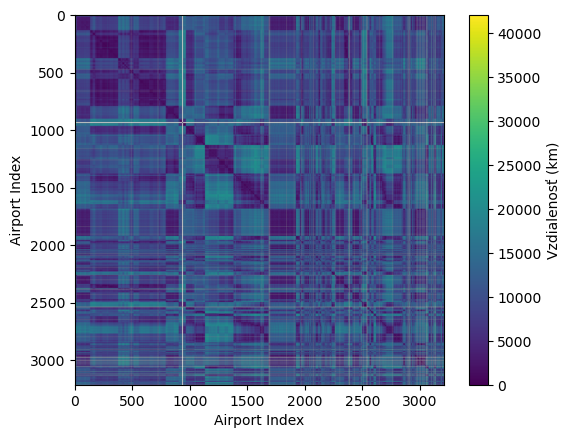

In [6]:
plt.imshow(layover_matrix)

plt.xlabel("Airport Index")
plt.ylabel("Airport Index")

color_bar = plt.colorbar()
color_bar.set_label("Vzdialenosť (km)")

plt.show()

# Distribution of distance

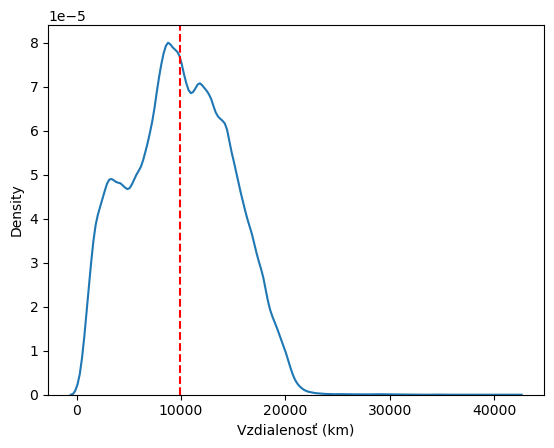

In [7]:
layover_values = layover_matrix.flatten()
layover_values = layover_values[np.isfinite(layover_values) & (layover_values >= 0)]

sns.kdeplot(data=layover_values)
plt.xlabel("Vzdialenosť (km)")

plt.axvline(np.mean(layover_values), linestyle="dashed", color="red")

plt.show()

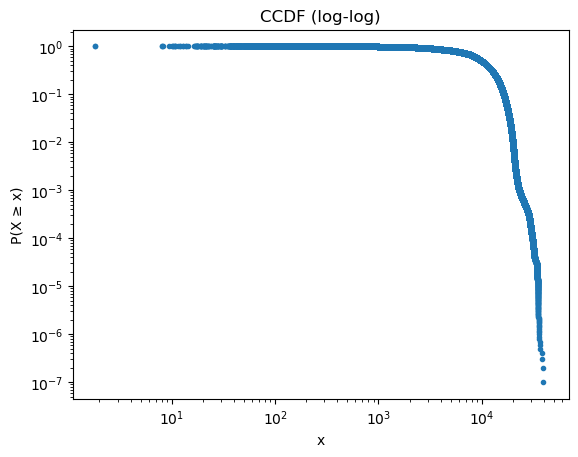

In [8]:
# zoradenie
x = np.sort(layover_values)
n = len(x)

# CCDF: P(X >= x) -> Ukazuje sa, že power law nie je zrovna kandidát :(
ccdf = 1.0 - np.arange(1, n+1) / n

plt.figure()
plt.loglog(x, ccdf, marker='.', linestyle='none')
plt.xlabel('x')
plt.ylabel('P(X ≥ x)')
plt.title('CCDF (log-log)')
plt.show()

# Diameter - maximum layover

In [28]:
def get_actual_route(predecessors, start_node, end_node):
    path = []
    curr = end_node
    
    # -9999 is the default "no path" value in SciPy's predecessor matrix
    if predecessors[start_node, curr] == -9999 and start_node != end_node:
        return "No path exists"
        
    while curr != -9999:
        path.append(curr)
        if curr == start_node:
            break
        curr = predecessors[start_node, curr]
        
    return path[::-1] # Reverse it to get start -> end

In [29]:
MAXIMUM = np.max(layover_matrix[np.isfinite(layover_matrix)])

#np.where(layover_matrix == MAXIMUM) # 2909, 2374

#print(nodes[nodes[" id"] == 2317])
#print(nodes[nodes[" id"] == 465])

# Fajný tripík :)
route = get_actual_route(pred_matrix, 2909, 2374)

for i in route:
    print(nodes[nodes[" id"] == i][[" city", " country"]].values)



[['Sinop' 'Turkey']]
[['Panama' 'Panama']]
[['Bocas Del Toro' 'Panama']]
[['San Jose' 'Costa Rica']]
[['Bogota' 'Colombia']]
[['Rio De Janeiro' 'Brazil']]
[['Luanda' 'Angola']]
[['Kinshasa' 'Congo (Kinshasa)']]
[['Lubumashi' 'Congo (Kinshasa)']]
[['Ndola' 'Zambia']]
[['Solwesi' 'Zambia']]


# Dĺžka priamych letov

In [17]:
edges.sort_values(by=" distance")

,# source,target,distance
57361,1931,1931,0.000000
63043,2350,2347,2.823546
63037,2347,2350,2.823546
62886,2292,2330,9.114073
62989,2330,2292,9.114073
...,...,...,...
39055,1639,1800,13812.512951
11203,411,2374,15942.117891
63101,2374,411,15942.117891
11190,409,2374,16087.303781
